#Data quality and frequency audit

Notebook này được viết để **kiểm tra tính hợp lệ của dữ liệu tần suất** trước khi bạn dùng chúng cho mô hình hóa.
Mục tiêu của notebook:

1. Xác định rõ file nào là **annual**, file nào là **quarterly**.
2. Đo mức độ “mượt quá mức” của chuỗi quý hiện tại.
3. Phát hiện dấu hiệu **quarterly giả lập từ annual**.
4. Đưa ra kết luận: phần nào có thể giữ ở thân bài, phần nào nên chuyển xuống phụ lục.


In [1]:

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

OUTPUT_DIR = Path("notebook_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

ANNUAL_PATH = Path("secondary_data_annual.csv")
QUARTERLY_PATH = Path("secondary_data_cleaned.csv")
PROCESSED_PATH = Path("secondary_data_processed.csv")
ACTUAL_QUARTERLY_OPTIONAL = Path("data_external/gso_real_gdp_quarterly.csv")


## 1. Load dữ liệu


In [2]:

def load_processed_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    # File secondary_data_processed.csv thường được lưu kèm index.
    if len(df.columns) > 0 and str(df.columns[0]).startswith("Unnamed"):
        df = df.rename(columns={df.columns[0]: "Date"})
    return df

if not ANNUAL_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy {ANNUAL_PATH}")
if not QUARTERLY_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy {QUARTERLY_PATH}")

annual = pd.read_csv(ANNUAL_PATH)
quarterly = pd.read_csv(QUARTERLY_PATH)
processed = load_processed_csv(PROCESSED_PATH) if PROCESSED_PATH.exists() else None

annual["Year"] = pd.to_datetime(annual["Year"].astype(int).astype(str) + "-12-31", errors="coerce")
quarterly["Year"] = pd.to_datetime(quarterly["Year"], errors="coerce")

if processed is not None:
    date_col = "Date" if "Date" in processed.columns else ("Year" if "Year" in processed.columns else processed.columns[0])
    processed[date_col] = pd.to_datetime(processed[date_col], errors="coerce")
    processed = processed.rename(columns={date_col: "Date"})

display(annual.head())
display(quarterly.head())
if processed is not None:
    display(processed.head())


,Year,GDP_Raw,Inflation,Interest_Rate,FDI_pct_GDP,Investment_pct_GDP,Export_pct_GDP,Unemployment_Rate,Gov_Spending_pct_GDP,GDP_Growth
0,1995-12-31,20.736,NaN,NaN,8.586,27.144,32.813,1.955,8.188,9.540
1,1996-12-31,24.657,5.675,20.100,9.713,28.103,40.868,1.930,8.353,9.340
2,1997-12-31,26.844,3.210,14.417,8.270,28.300,43.103,2.870,8.131,8.152
3,1998-12-31,27.210,7.266,14.400,6.141,29.050,44.848,2.290,7.624,5.764
4,1999-12-31,28.684,4.117,12.700,4.923,27.630,49.966,2.330,6.785,4.774


,Year,GDP_Raw,Inflation,Interest_Rate,FDI_pct_GDP,Investment_pct_GDP,Export_pct_GDP,Unemployment_Rate,Gov_Spending_pct_GDP,GDP_Growth
0,1995-04-01,21.703,7.527,24.370,8.864,27.381,34.799,1.949,8.228,9.491
1,1995-07-01,22.681,6.914,22.957,9.145,27.620,36.808,1.943,8.269,9.441
2,1995-10-01,23.669,6.295,21.529,9.429,27.861,38.838,1.936,8.311,9.391
3,1996-01-01,24.657,5.675,20.100,9.713,28.103,40.868,1.930,8.353,9.340
4,1996-04-01,25.201,5.062,18.687,9.354,28.152,41.424,2.164,8.297,9.045


,Date,GDP_Raw,Inflation,Interest_Rate,FDI_pct_GDP,Investment_pct_GDP,Export_pct_GDP,Unemployment_Rate,Gov_Spending_pct_GDP,GDP_Growth,...,Interest_Rate_lag2,log_GDP_diff1,log_GDP_diff4,Inflation_scaled,Interest_Rate_scaled,FDI_pct_GDP_scaled,Investment_pct_GDP_scaled,Export_pct_GDP_scaled,Unemployment_Rate_scaled,Gov_Spending_pct_GDP_scaled
0,1995-04-01,21.703,7.527,24.370,8.864,27.381,34.799,1.949,8.228,9.491,...,NaN,NaN,NaN,0.429131,3.912711,2.163500,-1.743410,-2.101290,0.197669,-0.009135
1,1995-07-01,22.681,6.914,22.957,9.145,27.620,36.808,1.943,8.269,9.441,...,NaN,0.044077,NaN,0.292007,3.500754,2.328200,-1.658207,-1.972395,0.184138,0.013473
2,1995-10-01,23.669,6.295,21.529,9.429,27.861,38.838,1.936,8.311,9.391,...,24.370,0.042639,NaN,0.153541,3.084423,2.494658,-1.572291,-1.842152,0.168351,0.036633
3,1996-01-01,24.657,5.675,20.100,9.713,28.103,40.868,1.930,8.353,9.340,...,22.957,0.040895,NaN,0.014851,2.667800,2.661116,-1.486019,-1.711909,0.154820,0.059793
4,1996-04-01,25.201,5.062,18.687,9.354,28.152,41.424,2.164,8.297,9.045,...,21.529,0.021823,0.149433,-0.122273,2.255843,2.450699,-1.468550,-1.676236,0.682539,0.028913


## 2. Audit tần suất và coverage


In [3]:

def infer_frequency(date_series: pd.Series) -> str:
    s = pd.Series(pd.to_datetime(date_series)).dropna().sort_values().unique()
    if len(s) < 3:
        return "Không đủ dữ liệu"
    diffs = pd.Series(s[1:] - s[:-1]).dt.days
    median_days = diffs.median()
    if 330 <= median_days <= 380:
        return "Annual"
    if 80 <= median_days <= 100:
        return "Quarterly"
    if 25 <= median_days <= 35:
        return "Monthly"
    return f"Khác ({median_days:.1f} ngày)"

audit_rows = []
for name, df, date_col in [
    ("secondary_data_annual.csv", annual, "Year"),
    ("secondary_data_cleaned.csv", quarterly, "Year"),
]:
    dates = pd.to_datetime(df[date_col]).dropna().sort_values()
    if len(dates) > 1:
        median_step = pd.Series(dates.iloc[1:].values - dates.iloc[:-1].values).dt.days.median()
    else:
        median_step = np.nan
    audit_rows.append({
        "file": name,
        "rows": len(df),
        "start": dates.min(),
        "end": dates.max(),
        "median_step_days": median_step,
        "inferred_frequency": infer_frequency(dates),
        "missing_values_total": int(df.isna().sum().sum()),
    })

if processed is not None:
    dates = pd.to_datetime(processed["Date"]).dropna().sort_values()
    if len(dates) > 1:
        median_step = pd.Series(dates.iloc[1:].values - dates.iloc[:-1].values).dt.days.median()
    else:
        median_step = np.nan
    audit_rows.append({
        "file": "secondary_data_processed.csv",
        "rows": len(processed),
        "start": dates.min(),
        "end": dates.max(),
        "median_step_days": median_step,
        "inferred_frequency": infer_frequency(dates),
        "missing_values_total": int(processed.isna().sum().sum()),
    })

audit_df = pd.DataFrame(audit_rows)
audit_df.to_csv(OUTPUT_DIR / "00_frequency_audit.csv", index=False)
display(audit_df)


,file,rows,start,end,median_step_days,inferred_frequency,missing_values_total
0,secondary_data_annual.csv,31,1995-12-31,2025-12-31,365.0,Annual,11
1,secondary_data_cleaned.csv,120,1995-04-01,2025-01-01,92.0,Quarterly,0
2,secondary_data_processed.csv,120,1995-04-01,2025-01-01,92.0,Quarterly,16


## 3. Dấu hiệu nội suy trong chuỗi quý

Ở đây ta đo ba thứ:

- **Độ mượt bất thường** của `GDP_yoy_pct_recalc` và `log_GDP_diff4`.
- **Độ đều của bước tăng theo quý** trong từng năm.
- **Tỉ lệ năm có increments gần như tuyến tính**.

Nếu các chỉ số này quá “đẹp”, đó là dấu hiệu dữ liệu quý được tạo từ annual bằng nội suy chứ không phải quan sát gốc.


In [4]:

def within_year_linearity_score(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    x = df[["Year", value_col]].dropna().copy()
    x["calendar_year"] = x["Year"].dt.year
    out = []
    for year, g in x.groupby("calendar_year"):
        g = g.sort_values("Year")
        if len(g) < 4:
            continue
        diffs = g[value_col].diff().dropna()
        if len(diffs) == 0:
            continue
        mean_abs = np.abs(diffs).mean()
        score = float(diffs.std() / mean_abs) if mean_abs > 0 else np.nan
        out.append({
            "calendar_year": year,
            "n_quarters": len(g),
            "mean_increment": float(diffs.mean()),
            "std_increment": float(diffs.std()),
            "linearity_score_std_over_meanabs": score,
        })
    return pd.DataFrame(out)

linearity_gdp = within_year_linearity_score(quarterly, "GDP_Raw")
linearity_gdp.to_csv(OUTPUT_DIR / "00_linearity_gdp_quarterly.csv", index=False)

summary_stats = {}
if processed is not None:
    for col in ["GDP_qoq_pct_recalc", "GDP_yoy_pct_recalc", "log_GDP_diff1", "log_GDP_diff4"]:
        if col in processed.columns:
            s = pd.to_numeric(processed[col], errors="coerce").dropna()
            summary_stats[col] = {
                "count": int(s.count()),
                "mean": float(s.mean()),
                "std": float(s.std()),
                "min": float(s.min()),
                "max": float(s.max()),
                "cv_pct": float((s.std() / s.mean()) * 100) if s.mean() != 0 else np.nan,
            }

summary_stats_df = pd.DataFrame(summary_stats).T
summary_stats_df.to_csv(OUTPUT_DIR / "00_processed_growth_diagnostics.csv")
display(summary_stats_df)
display(linearity_gdp.head(10))


,count,mean,std,min,max,cv_pct
GDP_qoq_pct_recalc,119.0,2.718688,1.785765,0.335270,9.578833,65.684783
GDP_yoy_pct_recalc,116.0,11.404151,6.978242,1.363433,38.849219,61.190373
log_GDP_diff1,119.0,0.026677,0.017158,0.003347,0.091474,64.318864
log_GDP_diff4,116.0,0.106146,0.060325,0.013542,0.328218,56.832215


,calendar_year,n_quarters,mean_increment,std_increment,linearity_score_std_over_meanabs
0,1996,4,0.545667,0.002887,0.005290
1,1997,4,0.091000,0.001000,0.010989
2,1998,4,0.367333,0.004041,0.011002
3,1999,4,0.620333,0.007024,0.011323
4,2000,4,0.377333,0.002309,0.006120
5,2001,4,0.593000,0.006000,0.010118
6,2002,4,1.119000,0.012000,0.010724
7,2003,4,1.464667,0.016503,0.011267
8,2004,4,3.045667,0.019348,0.006353
9,2005,4,2.178667,0.023502,0.010787


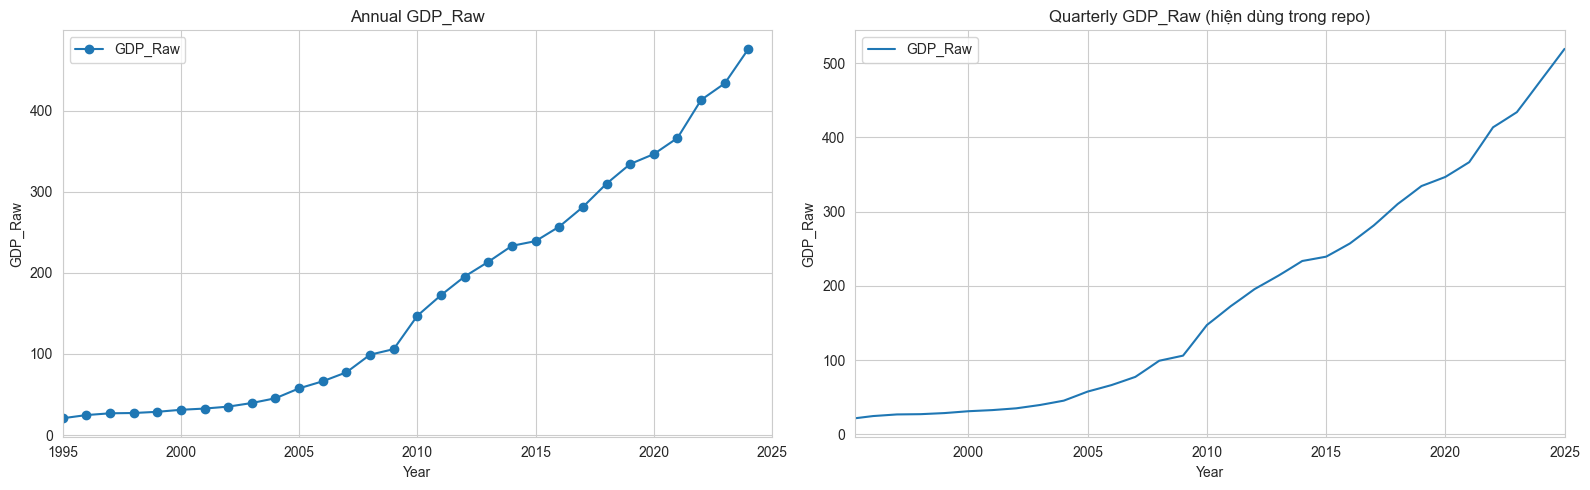

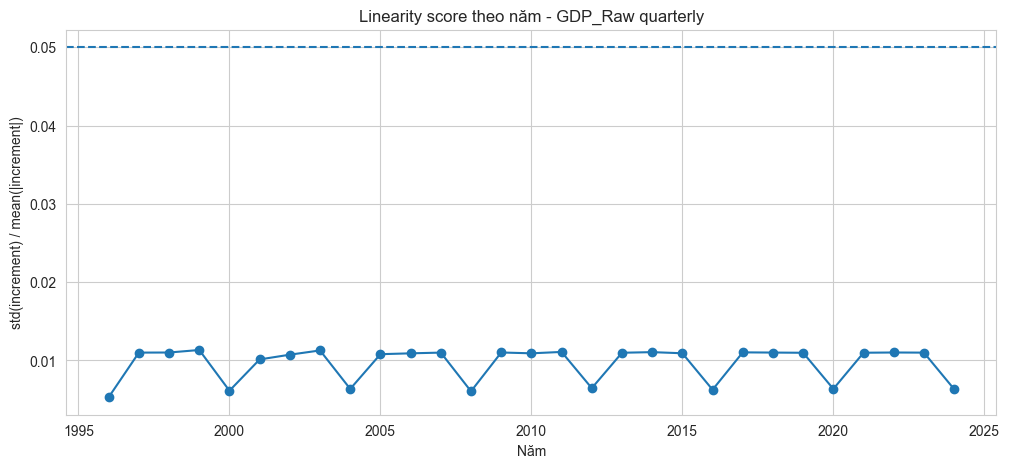

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

annual.plot(x="Year", y="GDP_Raw", ax=axes[0], marker="o", title="Annual GDP_Raw")
quarterly.plot(x="Year", y="GDP_Raw", ax=axes[1], title="Quarterly GDP_Raw (hiện dùng trong repo)")

axes[0].set_ylabel("GDP_Raw")
axes[1].set_ylabel("GDP_Raw")
plt.tight_layout()
plt.show()

if not linearity_gdp.empty:
    plt.figure(figsize=(12, 5))
    plt.plot(linearity_gdp["calendar_year"], linearity_gdp["linearity_score_std_over_meanabs"], marker="o")
    plt.axhline(0.05, linestyle="--")
    plt.title("Linearity score theo năm - GDP_Raw quarterly")
    plt.ylabel("std(increment) / mean(|increment|)")
    plt.xlabel("Năm")
    plt.show()


## 4. So sánh với dữ liệu quý thật (nếu bạn có)

Nếu bạn đã có file `data_external/gso_real_gdp_quarterly.csv`, notebook sẽ kiểm tra coverage và gợi ý thay thế ngay.
Kỳ vọng file này có ít nhất một cột thời gian (`Date` hoặc `Quarter`) và một cột giá trị GDP thực.


In [6]:

if ACTUAL_QUARTERLY_OPTIONAL.exists():
    actual_q = pd.read_csv(ACTUAL_QUARTERLY_OPTIONAL)
    possible_date_cols = [c for c in actual_q.columns if c.lower() in {"date", "quarter", "time"}]
    if not possible_date_cols:
        actual_q = actual_q.rename(columns={actual_q.columns[0]: "Date"})
    else:
        actual_q = actual_q.rename(columns={possible_date_cols[0]: "Date"})
    actual_q["Date"] = pd.to_datetime(actual_q["Date"], errors="coerce")
    display(actual_q.head())

    display(Markdown(
        f"""**Đã phát hiện dữ liệu quý thực**: `{ACTUAL_QUARTERLY_OPTIONAL}`.  
Bạn nên dùng file này để thay thế cho block quarterly nội suy hiện tại trong phần forecast, VAR, LSTM và sentiment-overlap."""
    ))
else:
    display(Markdown(
        """**Chưa có dữ liệu quý thực.**  
Nếu bạn tiếp tục dùng `secondary_data_cleaned.csv`, hãy ghi rõ trong báo cáo rằng đây là **quarterly-like interpolated data**, chỉ dùng cho robustness / appendix."""
    ))


**Chưa có dữ liệu quý thực.**  
Nếu bạn tiếp tục dùng `secondary_data_cleaned.csv`, hãy ghi rõ trong báo cáo rằng đây là **quarterly-like interpolated data**, chỉ dùng cho robustness / appendix.

## 5. Kết luận sẵn sàng để dán vào báo cáo


In [7]:

messages = []

if processed is not None and "GDP_yoy_pct_recalc" in processed.columns:
    yoy_std = float(pd.to_numeric(processed["GDP_yoy_pct_recalc"], errors="coerce").dropna().std())
    if yoy_std < 0.05:
        messages.append(
            f"- `GDP_yoy_pct_recalc` có độ lệch chuẩn rất thấp ({yoy_std:.6f}), cho thấy chuỗi quý rất mượt và có thể là sản phẩm nội suy."
        )

if processed is not None and "log_GDP_diff4" in processed.columns:
    lg_std = float(pd.to_numeric(processed["log_GDP_diff4"], errors="coerce").dropna().std())
    if lg_std < 0.001:
        messages.append(
            f"- `log_GDP_diff4` gần như hằng số (std = {lg_std:.6f}), đây là tín hiệu dữ liệu không phản ánh biến động quý thật."
        )

if not linearity_gdp.empty:
    low_score_share = float((linearity_gdp["linearity_score_std_over_meanabs"] < 0.05).mean())
    messages.append(
        f"- {low_score_share:.1%} số năm có bước tăng GDP quý gần tuyến tính trong năm; điều này phù hợp với dữ liệu nội suy từ annual."
    )

if not messages:
    messages.append("- Không phát hiện dấu hiệu mạnh của quarterly nội suy; bạn có thể kiểm tra thủ công thêm bằng nguồn GSO/NHNN.")

report_text = (
    "### Khuyến nghị phương pháp\n"
    + "\n".join(messages)
    + "\n\n"
    + "- Kết quả dùng annual official data có thể giữ ở thân bài.\n"
    + "- Kết quả dùng quarterly nội suy nên chuyển sang robustness / appendix.\n"
    + "- Nếu có dữ liệu quý thật từ GSO/NHNN, nên thay thế toàn bộ block forecast/VAR/LSTM hiện tại bằng dữ liệu đó."
)

display(Markdown(report_text))

with open(OUTPUT_DIR / "00_recommendation_text.md", "w", encoding="utf-8") as f:
    f.write(report_text)


### Khuyến nghị phương pháp
- 100.0% số năm có bước tăng GDP quý gần tuyến tính trong năm; điều này phù hợp với dữ liệu nội suy từ annual.

- Kết quả dùng annual official data có thể giữ ở thân bài.
- Kết quả dùng quarterly nội suy nên chuyển sang robustness / appendix.
- Nếu có dữ liệu quý thật từ GSO/NHNN, nên thay thế toàn bộ block forecast/VAR/LSTM hiện tại bằng dữ liệu đó.